In [1]:
# ============================================================
# ANALYSE BAYÉSIENNE BÉNIN — PHASE 2
# iSHEERO × DataCamp Hackathon 2026
# ============================================================
# Ce fichier est la référence unique. Il contient :
#   PARTIE A — Chargement & fusion multi-sources
#   PARTIE B — Analyses causales (corrélations croisées, lag)
#   PARTIE C — Modèles bayésiens (PyMC)
#   PARTIE D — Export des résultats pour le dashboard
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

# ── Palette cohérente avec Phase 1 ──────────────────────────
PALETTE = {
    "primary":   "#1D6FA4",
    "secondary": "#1D9E75",
    "accent":    "#E24B4A",
    "warning":   "#EF9F27",
    "neutral":   "#6C757D",
    "positive":  "#2ECC71",
    "negative":  "#E74C3C",
    "purple":    "#7F77DD",
    "amber":     "#BA7517",
}

# ── Chemins (adapter selon votre repo) ──────────────────────
DATA_DIR      = Path("../data/processed")
RAW_DIR       = Path("../data/raw")
OUTPUTS_DIR   = Path("../outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("ANALYSE BAYÉSIENNE BÉNIN — Phase 2")
print("=" * 60)

ANALYSE BAYÉSIENNE BÉNIN — Phase 2


In [2]:
# ============================================================
# PARTIE A — CHARGEMENT ET FUSION MULTI-SOURCES
# ============================================================

# ─── A.1 Chargement GDELT ───────────────────────────────────
def load_gdelt(path: Path) -> pd.DataFrame:
    """
    Charge le dataset GDELT nettoyé de Phase 1.
    Ajoute : year, month, quarter, year_month.
    """
    df = pd.read_csv(path, low_memory=False)
    df["EventDate"] = pd.to_datetime(
        df["SQLDATE"].astype(str), format="%Y%m%d", errors="coerce"
    )
    df["year"]       = df["EventDate"].dt.year
    df["month"]      = df["EventDate"].dt.month
    df["quarter"]    = df["EventDate"].dt.quarter
    df["year_month"] = df["EventDate"].dt.to_period("M").astype(str)
    for col in ["GoldsteinScale", "AvgTone", "NumMentions", "NumArticles"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    print(f"✅ GDELT chargé : {len(df):,} lignes | {df['year'].min()}-{df['year'].max()}")
    return df


# ─── A.2 Chargement Indicateurs Banque Mondiale (XLS) ────────
def load_wb_xls(path: Path) -> pd.DataFrame:
    """
    Charge le fichier Indicateurs_BEN.xls (Banque Mondiale).
    Transforme : format large (années en colonnes) → format long (une ligne par année).
    Retourne un DataFrame : year | indicator_code | indicator_name | value
    """
    try:
        df_raw = pd.read_excel(path, engine="xlrd", sheet_name="Data", header=3)
    except Exception as e:
        print(f"⚠️  Erreur chargement XLS: {e}")
        return pd.DataFrame()

    # Colonnes années : strings '1960' à '2025'
    year_cols = [c for c in df_raw.columns if str(c).isdigit()]
    for y in year_cols:
        df_raw[y] = pd.to_numeric(df_raw[y], errors="coerce")

    # Indicateurs PAG sélectionnés
    # (seuls ceux avec des données 2015+ seront retenus automatiquement)
    PAG_INDICATORS = {
        # Gouvernance économique
        "NY.GDP.PCAP.CD":       "pib_par_habitant_usd",
        "FP.CPI.TOTL.ZG":       "inflation_pct",
        "BX.KLT.DINV.WD.GD.ZS":"ide_entrants_pct_pib",
        "NE.GDI.TOTL.ZS":       "investissement_brut_pct_pib",
        "BN.CAB.XOKA.GD.ZS":    "balance_courante_pct_pib",
        # Santé
        "SH.DYN.MORT":          "mortalite_moins5_pour1000",
        "SP.DYN.LE00.IN":       "esperance_vie_ans",
        "SH.XPD.CHEX.GD.ZS":   "depenses_sante_pct_pib",
        "SH.STA.MMRT":          "mortalite_maternelle_100k",
        "SH.STA.BRTC.ZS":       "naissances_assistees_pct",
        # Développement social
        "EG.ELC.ACCS.ZS":       "acces_electricite_pct",
        "SH.H2O.BASW.ZS":       "acces_eau_potable_pct",
        "SI.POV.DDAY":          "pauvrete_3usd_pct",
        "SE.PRM.ENRL":          "eleves_primaire_nb",
        "SP.POP.TOTL":          "population_totale",
    }

    # Filtrer et pivoter en format long
    df_pag = df_raw[df_raw["Indicator Code"].isin(PAG_INDICATORS)].copy()
    df_long = df_pag.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_cols,
        var_name="year",
        value_name="value"
    )
    df_long["year"]           = df_long["year"].astype(int)
    df_long["indicator_name"] = df_long["Indicator Code"].map(PAG_INDICATORS)
    df_long                   = df_long.dropna(subset=["value"])
    df_long                   = df_long[df_long["year"] >= 2015]

    # Pivoter vers format large (une colonne par indicateur) pour jointure
    df_wb = df_long.pivot_table(
        index="year", columns="indicator_name", values="value", aggfunc="first"
    ).reset_index()
    df_wb.columns.name = None

    # Interpolation linéaire pour années manquantes (ex: pauvreté mesurée tous les 3 ans)
    df_wb = df_wb.set_index("year").reindex(range(2015, 2026))
    df_wb = df_wb.interpolate(method="linear", limit_direction="both")
    df_wb = df_wb.reset_index().rename(columns={"index": "year"})

    print(f"✅ Banque Mondiale : {len(df_wb)} années × {len(df_wb.columns)-1} indicateurs bruts")
    print(f"   Voici les colonnes BM: {[c for c in df_wb.columns if c != 'year']}")

    # Normalisation 0-1 pour le modèle bayésien
    for col in df_wb.columns:
        if col != "year":
            mn, mx = df_wb[col].min(), df_wb[col].max()
            if mx > mn:
                df_wb[f"{col}_norm"] = (df_wb[col] - mn) / (mx - mn)
            else:
                df_wb[f"{col}_norm"] = 0.5  # si constant, mettez à la valeur médiane

    print(f"✅ Après normalisation : {len(df_wb.columns)} colonnes (brutes + normes)")
    print(f"   Colonnes normalisées: {[c for c in df_wb.columns if c.endswith('_norm')]}")
    return df_wb


# ─── A.3 Chargement ACLED ────────────────────────────────────
def load_acled(path: Path) -> pd.DataFrame:
    """
    Charge le CSV ACLED Bénin téléchargé manuellement.
    URL de téléchargement: https://acleddata.com/data-export-tool/
    Filtres: Country=Benin, Year 2019-2025
    """
    if not path.exists():
        print(f"⚠️  ACLED non trouvé : {path}")
        print("   → Télécharger sur https://acleddata.com/data-export-tool/")
        print("   → Filtrer: Country=Benin, Year 2019-2025")
        print("   → Placer dans data/raw/acled_benin.csv")
        return pd.DataFrame()

    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.lower().str.replace(" ", "_")

    if "event_date" in df.columns:
        df["event_date"] = pd.to_datetime(df["event_date"], dayfirst=True, errors="coerce")
        df["year"]  = df["event_date"].dt.year
        df["month"] = df["event_date"].dt.month

    # Agrégation mensuelle
    agg = df.groupby(["year", "month"]).agg(
        acled_nb_incidents  = ("event_type", "count"),
        acled_nb_fatalities = ("fatalities", "sum") if "fatalities" in df.columns else ("event_type", "count"),
        acled_conflits      = ("event_type", lambda x: (x.isin(["Battles","Violence against civilians","Explosions/Remote violence"])).sum()),
    ).reset_index()

    print(f"✅ ACLED chargé : {len(df):,} incidents ({df['year'].min()}-{df['year'].max()})")
    return agg


# ─── A.4 Agrégation GDELT mensuelle ──────────────────────────
def aggregate_gdelt_monthly(df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrège GDELT par mois.
    Variables clés pour l'analyse causale :
    - ton_moyen_pondere : sentiment médiatique pondéré par NumMentions
    - goldstein_moyen   : niveau coopération/conflit
    - buzz_mensuel      : volume total de couverture
    - pct_conflit       : proportion d'événements conflictuels
    - volatilite_ton    : écart-type du ton (instabilité narrative)
    """
    agg = df.groupby(["year", "month"]).apply(
        lambda g: pd.Series({
            # Ton pondéré (comme Phase 1, Q2)
            "ton_moyen_pondere":   np.average(g["AvgTone"], weights=g["NumMentions"].fillna(1))
                                   if len(g) > 0 else np.nan,
            "goldstein_moyen":     g["GoldsteinScale"].mean(),
            "goldstein_std":       g["GoldsteinScale"].std(),
            "buzz_mensuel":        g["NumMentions"].sum(),
            "nb_evenements":       len(g),
            "nb_articles":         g["NumArticles"].sum() if "NumArticles" in g.columns else np.nan,
            "volatilite_ton":      g["AvgTone"].std(),
            # QuadClass si disponible
            "pct_conflit": (g["QuadClass"].isin([3, 4]).sum() / len(g) * 100)
                           if "QuadClass" in g.columns else np.nan,
            "pct_cooperation": (g["QuadClass"].isin([1, 2]).sum() / len(g) * 100)
                               if "QuadClass" in g.columns else np.nan,
        })
    ).reset_index()

    # Quarter
    agg["quarter"]    = ((agg["month"] - 1) // 3) + 1
    agg["year_month"] = agg.apply(
        lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1
    )

    # Normalisation pour le modèle bayésien
    for col in ["ton_moyen_pondere", "goldstein_moyen", "buzz_mensuel", "pct_conflit"]:
        if col in agg.columns:
            mn, mx = agg[col].min(), agg[col].max()
            if mx > mn:
                agg[f"{col}_norm"] = (agg[col] - mn) / (mx - mn)
            else:
                agg[f"{col}_norm"] = 0.5

    print(f"✅ GDELT agrégé : {len(agg)} mois-événements")
    print(f"   Colonnes GDELT: {[c for c in agg.columns]}")
    return agg


# ─── A.5 Dataset unifié ──────────────────────────────────────
def build_unified(df_gdelt_monthly, df_wb, df_acled=None) -> pd.DataFrame:
    """
    Fusionne toutes les sources sur (year, month).
    Les indicateurs BM sont annuels → broadcastés sur les 12 mois.
    """
    df = df_gdelt_monthly.copy()

    # Jointure BM (annuel → mensuel par broadcast)
    if df_wb is not None and not df_wb.empty:
        print(f"\n🔗 Fusion BM: {len(df)} lignes GDELT + {len(df_wb)} lignes BM")
        df = df.merge(df_wb, on="year", how="left")
        print(f"   → Après fusion: {len(df)} lignes")

    # Jointure ACLED (mensuel)
    if df_acled is not None and not df_acled.empty:
        print(f"\n🔗 Fusion ACLED: {len(df)} lignes + {len(df_acled)} lignes ACLED")
        df = df.merge(df_acled, on=["year", "month"], how="left")
        df["acled_nb_incidents"]  = df["acled_nb_incidents"].fillna(0)
        df["acled_nb_fatalities"] = df["acled_nb_fatalities"].fillna(0)
        print(f"   → Après fusion: {len(df)} lignes")

    df = df.sort_values(["year", "month"]).reset_index(drop=True)
    print(f"✅ Dataset unifié : {len(df)} lignes × {len(df.columns)} colonnes")
    return df


In [3]:
# ============================================================
# PARTIE B — ANALYSES CAUSALES CLASSIQUES
# (répondent aux questions Q1–Q8 via corrélations et lags)
# ============================================================

# ─── B.1 Analyse de corrélation croisée avec décalage ────────
def cross_lag_analysis(df_unified: pd.DataFrame,
                        gdelt_var: str,
                        wb_var: str,
                        max_lag: int = 12,
                        title: str = "") -> dict:
    """
    Calcule la corrélation entre une variable GDELT et un indicateur BM
    à différents décalages temporels (lags 0 à max_lag mois).

    Répond à Q1 : "Quels indicateurs précèdent de 1-3 mois la dégradation du ton ?"
    Répond à Q7 : "Les dépenses PAG améliorent-elles le ton dans les 12-24 mois ?"

    Interprétation :
    - lag > 0 : l'indicateur BM PRÉCÈDE le changement GDELT (causal potentiel)
    - lag < 0 : l'indicateur BM SUIT le changement GDELT (réaction potentielle)
    - |r| > 0.5 = corrélation forte, |r| > 0.3 = modérée
    """
    print(f"\n🔍 DEBUG cross_lag_analysis: {gdelt_var} vs {wb_var}")
    print(f"   Colonnes disponibles: {list(df_unified.columns)[:10]}...")
    
    # ✅ VALIDATION 1 : Les colonnes existent-elles ?
    if gdelt_var not in df_unified.columns:
        print(f"❌ ERREUR : Colonne GDELT '{gdelt_var}' NOT FOUND")
        print(f"   Colonnes disponibles: {[c for c in df_unified.columns if 'ton' in c.lower() or 'goldstein' in c.lower()]}")
        return {}
    
    if wb_var not in df_unified.columns:
        print(f"❌ ERREUR : Colonne BM '{wb_var}' NOT FOUND")
        print(f"   Colonnes disponibles: {[c for c in df_unified.columns if 'pib' in c.lower() or 'sante' in c.lower()]}")
        return {}

    gdelt_series = df_unified[gdelt_var].values
    wb_series    = df_unified[wb_var].values

    # ✅ VALIDATION 2 : Les données ne sont pas vides ?
    print(f"   {gdelt_var}: {len(gdelt_series)} points | NaN: {np.isnan(gdelt_series).sum()} | Min/Max: {np.nanmin(gdelt_series):.2f}/{np.nanmax(gdelt_series):.2f}")
    print(f"   {wb_var}: {len(wb_series)} points | NaN: {np.isnan(wb_series).sum()} | Min/Max: {np.nanmin(wb_series):.2f}/{np.nanmax(wb_series):.2f}")

    if np.isnan(gdelt_series).sum() == len(gdelt_series):
        print(f"❌ ERREUR : {gdelt_var} est entièrement NaN !")
        return {}
    
    if np.isnan(wb_series).sum() == len(wb_series):
        print(f"❌ ERREUR : {wb_var} est entièrement NaN !")
        return {}

    results = {}
    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            # indicateur BM décalé de 'lag' mois vers le futur
            x = wb_series[:-lag]
            y = gdelt_series[lag:]
        elif lag < 0:
            x = wb_series[-lag:]
            y = gdelt_series[:lag]
        else:
            x, y = wb_series, gdelt_series

        # Retirer les NaN
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 5:
            results[lag] = {"r": np.nan, "p": np.nan, "n": 0}
            continue

        try:
            r, p = stats.pearsonr(x[mask], y[mask])
            results[lag] = {"r": r, "p": p, "n": mask.sum()}
        except Exception as e:
            print(f"   ⚠️  Lag {lag}: erreur {e}")
            results[lag] = {"r": np.nan, "p": np.nan, "n": mask.sum()}

    # Visualisation
    lags  = list(results.keys())
    rs    = np.array([results[l]["r"] for l in lags])
    ps    = [results[l]["p"] for l in lags]
    sig   = [p < 0.05 if not np.isnan(p) else False for p in ps]

    # ✅ VALIDATION 3 : Y a-t-il au moins une corrélation calculable ?
    valid_rs = rs[~np.isnan(rs)]
    if len(valid_rs) == 0:
        print(f"❌ ERREUR : Aucune corrélation calculable pour {gdelt_var} vs {wb_var}")
        print(f"   Vérifier que les séries ont suffisamment de points non-NaN")
        return {}

    print(f"   ✅ {len(valid_rs)} corrélations calculées")

    fig, ax = plt.subplots(figsize=(12, 5))
    colors_bar = [
        PALETTE["accent"] if (r < -0.3 and s) else
        PALETTE["secondary"] if (r > 0.3 and s) else
        PALETTE["neutral"]
        for r, s in zip(rs, sig)
    ]
    bars = ax.bar(lags, rs, color=colors_bar, alpha=0.85, edgecolor="white", linewidth=0.5)

    ax.axhline(0,    color="black",           linewidth=0.8)
    ax.axhline(0.3,  color=PALETTE["secondary"], linewidth=1, linestyle="--", alpha=0.6, label="r = ±0.3 (modéré)")
    ax.axhline(-0.3, color=PALETTE["secondary"], linewidth=1, linestyle="--", alpha=0.6)
    ax.axhline(0.5,  color=PALETTE["positive"],  linewidth=1, linestyle=":",  alpha=0.6, label="r = ±0.5 (fort)")
    ax.axhline(-0.5, color=PALETTE["positive"],  linewidth=1, linestyle=":",  alpha=0.6)
    ax.axvline(0,    color=PALETTE["warning"],    linewidth=1.5, linestyle="-.", alpha=0.7, label="Lag 0 (simultané)")

    # ✅ VALIDATION 4 : Annoter le lag optimal EN TOUTE SÉCURITÉ
    valid_indices = ~np.isnan(rs)
    if np.any(valid_indices):
        best_idx = np.nanargmax(np.abs(rs[valid_indices]))
        best_lag_idx = np.where(valid_indices)[0][best_idx]
        best_lag = lags[best_lag_idx]
        best_r   = results[best_lag]["r"]
        
        ax.annotate(
            f"Lag optimal : {best_lag} mois\nr = {best_r:.2f}",
            xy=(best_lag, best_r),
            xytext=(best_lag + 1.5, best_r + 0.05 * np.sign(best_r)),
            fontsize=9, color=PALETTE["primary"],
            arrowprops=dict(arrowstyle="->", color=PALETTE["primary"], lw=1)
        )
        print(f"   Lag optimal: {best_lag} mois | r = {best_r:.3f} | p = {results[best_lag]['p']:.4f}")

    ax.set_xlabel("Décalage temporel (mois) — positif = indicateur précède GDELT", fontsize=10)
    ax.set_ylabel("Corrélation de Pearson (r)", fontsize=10)
    ax.set_title(
        f"{title or f'{gdelt_var} × {wb_var}'}\n"
        "Analyse de corrélation croisée avec décalage temporel",
        fontsize=12, fontweight="bold"
    )
    ax.legend(fontsize=9)
    ax.set_xticks(lags)

    note = ("Lecture : lag > 0 → l'indicateur précède le ton médiatique (lien causal potentiel). "
            "Barres colorées = corrélation significative (p < 0.05).")
    ax.text(0.01, 0.02, note, transform=ax.transAxes, fontsize=8,
            color=PALETTE["neutral"], style="italic")

    plt.tight_layout()
    fname = f"lag_{gdelt_var[:10]}_{wb_var[:15]}.png"
    plt.savefig(OUTPUTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Graphique lag sauvegardé : {fname}")

    return results

In [4]:
# ─── B.2 Matrice de corrélation multi-variables ──────────────
def correlation_matrix(df_unified: pd.DataFrame,
                        gdelt_vars: list,
                        wb_vars: list,
                        title: str = "Corrélations GDELT × Indicateurs PAG") -> pd.DataFrame:
    """
    Calcule et visualise la matrice de corrélation entre
    variables GDELT et indicateurs PAG à lag 0.

    Répond à Q3 : profil de risque et différenciation géographique.
    Répond à Q5 : ton médiatique santé vs. réalité épidémiologique.
    """
    all_vars = [v for v in gdelt_vars + wb_vars if v in df_unified.columns]
    df_sub   = df_unified[all_vars].dropna()
    corr     = df_sub.corr()

    fig, ax = plt.subplots(figsize=(max(10, len(all_vars)), max(8, len(all_vars) * 0.7)))

    # Heatmap manuelle avec matplotlib
    im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")

    ax.set_xticks(range(len(all_vars)))
    ax.set_yticks(range(len(all_vars)))
    ax.set_xticklabels(all_vars, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(all_vars, fontsize=9)

    # Annotations dans chaque cellule
    for i in range(len(all_vars)):
        for j in range(len(all_vars)):
            val = corr.values[i, j]
            color = "black" if abs(val) < 0.7 else "white"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color=color)

    plt.colorbar(im, ax=ax, label="Coefficient de corrélation (r)")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    ax.set_xlabel("Variables (colonnes)")
    ax.set_ylabel("Variables (lignes)")

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Matrice de corrélation sauvegardée")
    return corr


# ─── B.3 Détection des pics et événements déclencheurs ───────
def detect_spikes(df_monthly: pd.DataFrame,
                   var: str = "ton_moyen_pondere",
                   threshold_std: float = 1.5) -> pd.DataFrame:
    """
    Identifie les mois où la variable dépasse ±threshold_std
    écarts-types (pics de ton négatif, de buzz, etc.).

    Répond à Q1 (pic décembre) et Q4 (choc sécuritaire → seuil alerte).
    """
    mn   = df_monthly[var].mean()
    std  = df_monthly[var].std()
    low  = mn - threshold_std * std
    high = mn + threshold_std * std

    spikes = df_monthly[
        (df_monthly[var] < low) | (df_monthly[var] > high)
    ].copy()
    spikes["type_spike"] = np.where(spikes[var] < low, "négatif_extrême", "positif_extrême")

    print(f"✅ Pics détectés ({var}) : {len(spikes)} mois")
    print(f"   Seuils : < {low:.2f} (négatif) | > {high:.2f} (positif)")
    print(spikes[["year", "month", var, "type_spike"]].to_string(index=False))

    return spikes


# ============================================================
# PARTIE C — MODÈLES BAYÉSIENS (PyMC)
# ============================================================
# Les modèles répondent aux questions Q1, Q4, Q7, Q8
# avec quantification explicite de l'incertitude.
# ============================================================

def check_pymc():
    """Vérifie si PyMC est disponible, sinon donne les instructions."""
    try:
        import pymc as pm
        print(f"✅ PyMC disponible")
        return True
    except ImportError:
        print("⚠️  PyMC non installé. Installer avec :")
        print("   pip install pymc")
        print("   ou : conda install -c conda-forge pymc")
        return False


In [5]:
# ─── C.1 Modèle bayésien linéaire — Q1 & Q7 ─────────────────
def bayesian_linear_regression(df: pd.DataFrame,
                                 y_var: str,
                                 x_vars: list,
                                 model_name: str = "model") -> dict:
    """
    Modèle de régression linéaire bayésienne.

    Répond à Q1 : "Quels indicateurs prédisent la dégradation du ton ?"
    Répond à Q7 : "Les investissements PAG améliorent-ils le ton à 12-24 mois ?"

    Avantage vs. régression classique :
    - Quantifie l'incertitude sur chaque coefficient (HDI 94%)
    - Permet des priors informés par la littérature sur les pays sahéliens
    - Gère les données manquantes implicitement
    - Produit des distributions postérieures → intervalles de décision

    Structure du modèle :
        ton[t] ~ Normal(mu[t], sigma)
        mu[t]  = alpha + beta_1 * X1[t-lag] + ... + beta_k * Xk[t-lag]

        Priors (légèrement informatifs) :
        alpha  ~ Normal(mean(ton), sd(ton))    — intercepte autour de la moyenne observée
        beta_k ~ Normal(0, 1)                  — coefficients probablement petits
        sigma  ~ HalfNormal(sd(ton))           — bruit probablement de l'ordre de la variabilité
    """
    if not check_pymc():
        return {}

    import pymc as pm
    import arviz as az

    # Préparer les données
    vars_needed = [y_var] + x_vars
    df_model    = df[vars_needed].dropna().copy()

    if len(df_model) < 10:
        print(f"⚠️  Pas assez de données ({len(df_model)} lignes) pour {model_name}")
        return {}

    y = df_model[y_var].values
    X = df_model[x_vars].values  # shape (N, k)

    print(f"\n🔵 Modèle bayésien : {model_name}")
    print(f"   Variable cible    : {y_var}")
    print(f"   Prédicteurs       : {x_vars}")
    print(f"   Observations      : {len(df_model)}")

    with pm.Model() as model:
        # ── Données ──────────────────────────────────────────
        X_data = pm.Data("X", X)
        y_data = pm.Data("y", y)

        # ── Priors ───────────────────────────────────────────
        # Alpha : on s'attend à un ton moyen proche de la moyenne observée
        alpha = pm.Normal("alpha", mu=float(np.mean(y)), sigma=float(np.std(y)))

        # Betas : prior légèrement informatif centré sur 0
        # (on ne sait pas a priori si l'effet est positif ou négatif)
        betas = pm.Normal("betas", mu=0, sigma=1, shape=len(x_vars))

        # Sigma : bruit observé probablement de l'ordre de la variabilité du ton
        sigma = pm.HalfNormal("sigma", sigma=float(np.std(y)))

        # ── Vraisemblance ─────────────────────────────────────
        mu = alpha + pm.math.dot(X_data, betas)
        likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y_data)

        # ── Inférence MCMC ────────────────────────────────────
        # Utiliser NUTS (No U-Turn Sampler) — algorithme optimal pour modèles continus
        print("   Échantillonnage MCMC en cours...")
        trace = pm.sample(
            draws=2000,         # nombre d'échantillons postérieurs
            tune=1000,          # phase de chauffe
            chains=4,           # 4 chaînes parallèles pour diagnostics de convergence
            target_accept=0.9,  # acceptance rate cible (élevé = pas de divergences)
            return_inferencedata=True,
            progressbar=True
        )

    # ── Diagnostics ──────────────────────────────────────────
    r_hat  = az.rhat(trace)
    print("\n   Diagnostics de convergence (R-hat — doit être < 1.05) :")
    for var_name in ["alpha", "betas", "sigma"]:
        try:
            rh = float(r_hat[var_name].max())
            status = "✅ OK" if rh < 1.05 else "⚠️  Problème de convergence"
            print(f"     {var_name}: R-hat = {rh:.4f} {status}")
        except Exception:
            pass

    # ── Résumé postérieur ─────────────────────────────────────
    summary = az.summary(trace, var_names=["alpha", "betas", "sigma"],
                          hdi_prob=0.94)
    print("\n   Résumé postérieur (HDI 94%) :")
    print(summary.to_string())

    # ── Interprétation des betas ──────────────────────────────
    print(f"\n   Interprétation des coefficients :")
    betas_post = trace.posterior["betas"].values.reshape(-1, len(x_vars))
    for i, var in enumerate(x_vars):
        b_mean = float(np.mean(betas_post[:, i]))
        b_hdi  = az.hdi(betas_post[:, i], hdi_prob=0.94)
        prob_positive = float(np.mean(betas_post[:, i] > 0))
        direction = "↑ améliore le ton" if b_mean > 0 else "↓ dégrade le ton"
        print(f"     {var:40s} : β = {b_mean:+.3f} "
              f"[{float(b_hdi[0]):+.3f}, {float(b_hdi[1]):+.3f}] "
              f"| P(β>0) = {prob_positive:.2f} {direction}")

    # ── Visualisation des posteriors ──────────────────────────
    fig, axes = plt.subplots(
        len(x_vars), 2,
        figsize=(12, max(4, len(x_vars) * 2.5))
    )
    if len(x_vars) == 1:
        axes = axes.reshape(1, -1)

    for i, var in enumerate(x_vars):
        b_samples = betas_post[:, i]

        # Densité postérieure
        axes[i, 0].hist(b_samples, bins=50, color=PALETTE["primary"],
                        alpha=0.7, density=True, edgecolor="white")
        axes[i, 0].axvline(0, color=PALETTE["accent"], linewidth=2,
                            linestyle="--", label="β = 0 (pas d'effet)")
        hdi = az.hdi(b_samples, hdi_prob=0.94)
        axes[i, 0].axvspan(float(hdi[0]), float(hdi[1]),
                            alpha=0.2, color=PALETTE["secondary"],
                            label=f"HDI 94% [{float(hdi[0]):.2f}, {float(hdi[1]):.2f}]")
        axes[i, 0].set_title(f"β({var[:30]})", fontsize=10)
        axes[i, 0].legend(fontsize=8)
        axes[i, 0].set_xlabel("Valeur du coefficient", fontsize=9)

        # Trace MCMC (convergence visuelle)
        for chain in range(min(4, trace.posterior["betas"].shape[0])):
            samples_chain = trace.posterior["betas"].values[chain, :, i]
            axes[i, 1].plot(samples_chain, alpha=0.5, linewidth=0.5,
                             label=f"Chaîne {chain+1}")
        axes[i, 1].set_title(f"Trace MCMC — {var[:30]}", fontsize=10)
        axes[i, 1].set_xlabel("Itération", fontsize=9)
        axes[i, 1].legend(fontsize=7)

    plt.suptitle(f"Distributions postérieures — {model_name}", fontsize=13,
                  fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = f"bayes_{model_name.replace(' ', '_')}.png"
    plt.savefig(OUTPUTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Visualisation bayésienne sauvegardée : {fname}")

    return {"trace": trace, "summary": summary, "betas_mean": {
        var: float(np.mean(betas_post[:, i]))
        for i, var in enumerate(x_vars)
    }}


# ─── C.2 Modèle de seuil bayésien — Q4 ──────────────────────
def bayesian_threshold_model(df: pd.DataFrame,
                               goldstein_var: str = "goldstein_moyen",
                               outcome_var: str   = "acled_nb_incidents",
                               model_name: str    = "seuil_alerte") -> dict:
    """
    Modèle de détection de seuil bayésien.

    Répond à Q4 : "À partir de quel niveau de GoldsteinScale le risque
    sécuritaire augmente-t-il significativement ?"

    Ce modèle produit :
    - Un seuil de GoldsteinScale avec intervalle de crédibilité
    - La probabilité que le risque dépasse un niveau critique
    - Un indicateur d'alerte actionnable pour les décideurs

    Structure :
        incidents[t] ~ Poisson(lambda[t])
        log(lambda[t]) = alpha + beta * I(goldstein[t] < seuil)
        seuil ~ Uniform(min_goldstein, max_goldstein)
    """
    if not check_pymc():
        return {}

    import pymc as pm
    import arviz as az

    df_m = df[[goldstein_var, outcome_var]].dropna().copy()
    if len(df_m) < 10:
        print(f"⚠️  Données insuffisantes pour le modèle de seuil")
        return {}

    g_vals = df_m[goldstein_var].values.astype(float)
    y_vals = df_m[outcome_var].values.astype(float)

    # Discrétiser : incidents = 1 si > médiane, 0 sinon (pour modèle logistique)
    y_binary = (y_vals > np.median(y_vals)).astype(float)

    print(f"\n🔵 Modèle de seuil bayésien : {model_name}")
    print(f"   GoldsteinScale : [{g_vals.min():.2f}, {g_vals.max():.2f}]")
    print(f"   % mois avec incidents élevés : {y_binary.mean()*100:.1f}%")

    with pm.Model() as threshold_model:
        # Le seuil est une inconnue — on le fait inférer
        threshold = pm.Uniform(
            "threshold",
            lower=float(g_vals.min()),
            upper=float(g_vals.max())
        )

        # Effet du passage sous le seuil
        alpha = pm.Normal("alpha", mu=0, sigma=2)
        beta  = pm.Normal("beta_threshold", mu=1, sigma=2)

        # Probabilité d'incidents élevés
        below_threshold = pm.math.switch(g_vals < threshold, 1.0, 0.0)
        p = pm.Deterministic("p", pm.math.sigmoid(alpha + beta * below_threshold))

        likelihood = pm.Bernoulli("likelihood", p=p, observed=y_binary)

        trace = pm.sample(2000, tune=1000, chains=4, target_accept=0.9,
                           return_inferencedata=True, progressbar=True)

    # Résultats
    threshold_samples = trace.posterior["threshold"].values.flatten()
    threshold_mean    = float(np.mean(threshold_samples))
    threshold_hdi     = az.hdi(threshold_samples, hdi_prob=0.94)

    print(f"\n   ✅ SEUIL D'ALERTE DÉTECTÉ :")
    print(f"      GoldsteinScale < {threshold_mean:.2f} "
          f"[HDI 94% : {float(threshold_hdi[0]):.2f}, {float(threshold_hdi[1]):.2f}]")
    print(f"      Interprétation : quand le GoldsteinScale tombe sous {threshold_mean:.2f},")
    print(f"      la probabilité d'incidents sécuritaires élevés augmente significativement.")
    print(f"      → DÉCISION : déclencher alerte et renforcer présence dans la zone.")

    # Visualisation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter avec seuil
    colors_pts = [PALETTE["accent"] if g < threshold_mean else PALETTE["secondary"]
                  for g in g_vals]
    ax1.scatter(g_vals, y_vals, c=colors_pts, alpha=0.7, s=60, edgecolors="white", linewidths=0.5)
    ax1.axvline(threshold_mean, color=PALETTE["warning"], linewidth=2.5,
                label=f"Seuil bayésien : {threshold_mean:.2f}")
    ax1.axvspan(float(threshold_hdi[0]), float(threshold_hdi[1]),
                alpha=0.2, color=PALETTE["warning"], label=f"Incertitude HDI 94%")
    ax1.set_xlabel(f"GoldsteinScale (↑ coopération, ↓ conflit)", fontsize=10)
    ax1.set_ylabel(f"Incidents ACLED", fontsize=10)
    ax1.set_title("Détection du seuil d'alerte sécuritaire", fontsize=11, fontweight="bold")
    ax1.legend(fontsize=9)

    # Distribution postérieure du seuil
    ax2.hist(threshold_samples, bins=60, color=PALETTE["amber"],
             alpha=0.8, density=True, edgecolor="white")
    ax2.axvline(threshold_mean, color=PALETTE["accent"], linewidth=2,
                label=f"Moyenne : {threshold_mean:.2f}")
    ax2.axvspan(float(threshold_hdi[0]), float(threshold_hdi[1]),
                alpha=0.3, color=PALETTE["primary"],
                label=f"HDI 94% [{float(threshold_hdi[0]):.2f}, {float(threshold_hdi[1]):.2f}]")
    ax2.set_xlabel("Valeur du seuil (GoldsteinScale)", fontsize=10)
    ax2.set_ylabel("Densité postérieure", fontsize=10)
    ax2.set_title("Distribution postérieure du seuil", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=9)

    note = ("Zone rouge : GoldsteinScale sous le seuil → risque sécuritaire élevé. "
            "Zone verte : au-dessus du seuil → risque modéré.")
    fig.text(0.5, -0.02, note, ha="center", fontsize=9,
             color=PALETTE["neutral"], style="italic")

    plt.suptitle(f"Modèle de seuil bayésien — {model_name}", fontsize=13,
                  fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "bayes_threshold_alerte.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Modèle de seuil sauvegardé")

    return {
        "trace": trace,
        "threshold_mean": threshold_mean,
        "threshold_hdi": threshold_hdi,
        "alerte_active": threshold_mean  # valeur à utiliser dans le dashboard
    }


# ─── C.3 Modèle de simulation de scénarios — Q8 ─────────────
def bayesian_scenario_simulation(trace_results: dict,
                                   scenarios: dict,
                                   y_var: str = "ton_moyen_pondere") -> pd.DataFrame:
    """
    Utilise le modèle bayésien entraîné pour simuler des scénarios
    contrefactuels d'investissement PAG.

    Répond à Q8 : "Quel scénario aurait le mieux réduit la dissonance ?"

    scenarios : dict de scénarios, ex :
        {
          "Hausse budget santé +20%"   : {"depenses_sante_pct_pib_norm": 0.8, ...},
          "Hausse budget éducation +20%": {"pib_par_habitant_usd_norm":  0.7, ...},
          "Status quo"                 : {"depenses_sante_pct_pib_norm": 0.5, ...},
        }

    Retourne un DataFrame avec pour chaque scénario :
    - ton_prédit_moyen
    - HDI 94% de la prédiction (intervalle de crédibilité)
    - probabilité que le ton soit > -0.5 (acceptable)
    """
    if not trace_results or "trace" not in trace_results:
        print("⚠️  Pas de trace disponible. Exécuter d'abord bayesian_linear_regression().")
        return pd.DataFrame()

    import arviz as az
    trace   = trace_results["trace"]
    x_vars  = trace_results.get("x_vars", [])

    alpha_samples = trace.posterior["alpha"].values.flatten()
    betas_samples = trace.posterior["betas"].values.reshape(-1, len(x_vars))

    results_list = []
    for scenario_name, scenario_values in scenarios.items():
        X_scenario = np.array([scenario_values.get(var, 0) for var in x_vars])
        y_pred     = alpha_samples + betas_samples @ X_scenario

        hdi = az.hdi(y_pred, hdi_prob=0.94)
        results_list.append({
            "scénario":             scenario_name,
            "ton_prédit_moyen":     float(np.mean(y_pred)),
            "ton_prédit_médiane":   float(np.median(y_pred)),
            "hdi_bas":              float(hdi[0]),
            "hdi_haut":             float(hdi[1]),
            "prob_ton_acceptable":  float(np.mean(y_pred > -0.5)),
            "incertitude":          float(np.std(y_pred)),
        })

    df_scenarios = pd.DataFrame(results_list).sort_values("ton_prédit_moyen", ascending=False)

    # Visualisation
    fig, ax = plt.subplots(figsize=(10, max(5, len(scenarios) * 1.2)))

    colors_bar = [PALETTE["secondary"] if t > -0.5 else PALETTE["accent"]
                  for t in df_scenarios["ton_prédit_moyen"]]
    y_pos = range(len(df_scenarios))

    bars = ax.barh(y_pos, df_scenarios["ton_prédit_moyen"],
                   color=colors_bar, alpha=0.85,
                   edgecolor="white", linewidth=0.5)

    # Intervalles de crédibilité
    for i, (_, row) in enumerate(df_scenarios.iterrows()):
        ax.errorbar(
            row["ton_prédit_moyen"], i,
            xerr=[[row["ton_prédit_moyen"] - row["hdi_bas"]],
                   [row["hdi_haut"] - row["ton_prédit_moyen"]]],
            fmt="none", color="black", capsize=5, linewidth=1.5
        )
        ax.text(row["hdi_haut"] + 0.01, i,
                f"P(OK)={row['prob_ton_acceptable']:.0%}",
                va="center", fontsize=8, color=PALETTE["neutral"])

    ax.axvline(-0.5, color=PALETTE["warning"], linewidth=2, linestyle="--",
               label="Seuil : ton acceptable (> -0.5)")
    ax.axvline(0,   color="black", linewidth=0.8, linestyle="-")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_scenarios["scénario"], fontsize=10)
    ax.set_xlabel("Ton médiatique prédit (AvgTone pondéré)", fontsize=10)
    ax.set_title("Simulation de scénarios d'investissement PAG\n"
                  "Quel investissement améliore le plus la perception internationale du Bénin ?",
                  fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

    note = ("Les barres d'erreur représentent l'HDI 94% (intervalle de crédibilité bayésien). "
            "P(OK) = probabilité que le ton dépasse le seuil acceptable.")
    ax.text(0.01, -0.08, note, transform=ax.transAxes, fontsize=8,
             color=PALETTE["neutral"], style="italic")

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "bayes_scenarios_pag.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n✅ Résultats simulation de scénarios :")
    print(df_scenarios[["scénario", "ton_prédit_moyen", "hdi_bas",
                          "hdi_haut", "prob_ton_acceptable"]].to_string(index=False))
    return df_scenarios



In [6]:

# ============================================================
# PARTIE D — EXPORT DES RÉSULTATS POUR LE DASHBOARD
# ============================================================

def export_for_dashboard(df_unified: pd.DataFrame,
                          lag_results: dict = None,
                          threshold_result: dict = None,
                          scenario_results: pd.DataFrame = None) -> None:
    """
    Exporte tous les résultats analytiques en JSON et CSV
    pour le dashboard Streamlit (ou Plotly Dash).

    Le DA et le ML Engineer peuvent brancher directement
    ces fichiers dans le dashboard sans re-exécuter les modèles.
    """
    OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

    # 1. Dataset unifié mensuel (base de toutes les visualisations)
    df_unified.to_csv(OUTPUTS_DIR / "dashboard_dataset.csv", index=False)
    print("✅ Exporté : dashboard_dataset.csv")

    # 2. Seuil d'alerte bayésien (pour le widget de décision dans le dashboard)
    if threshold_result:
        alerte = {
            "seuil_goldstein":    threshold_result.get("threshold_mean"),
            "hdi_bas":            float(threshold_result["threshold_hdi"][0]),
            "hdi_haut":           float(threshold_result["threshold_hdi"][1]),
            "interpretation":     (
                f"Quand GoldsteinScale < {threshold_result.get('threshold_mean', 0):.2f}, "
                "le risque sécuritaire est élevé. Décision : renforcer présence terrain."
            ),
            "date_calcul":        pd.Timestamp.now().isoformat()
        }
        import json
        with open(OUTPUTS_DIR / "alerte_securitaire.json", "w", encoding="utf-8") as f:
            json.dump(alerte, f, indent=2, ensure_ascii=False)
        print("✅ Exporté : alerte_securitaire.json")

    # 3. Résultats des scénarios (pour le simulateur interactif)
    if scenario_results is not None and not scenario_results.empty:
        scenario_results.to_csv(OUTPUTS_DIR / "scenarios_pag.csv", index=False)
        print("✅ Exporté : scenarios_pag.csv")

    # 4. Statistiques mensuelles agrégées (pour KPIs du dashboard)
    kpis = {
        "ton_moyen_global":       float(df_unified["ton_moyen_pondere"].mean()),
        "mois_le_plus_negatif":   df_unified.loc[df_unified["ton_moyen_pondere"].idxmin(), "year_month"],
        "mois_le_plus_positif":   df_unified.loc[df_unified["ton_moyen_pondere"].idxmax(), "year_month"],
        "goldstein_moyen_global": float(df_unified["goldstein_moyen"].mean()),
        "buzz_total":             int(df_unified["buzz_mensuel"].sum()),
        "nb_mois_analyses":       len(df_unified),
    }
    import json
    with open(OUTPUTS_DIR / "kpis_dashboard.json", "w", encoding="utf-8") as f:
        json.dump(kpis, f, indent=2, ensure_ascii=False)
    print("✅ Exporté : kpis_dashboard.json")

    print(f"\n📁 Tous les fichiers de sortie dans : {OUTPUTS_DIR.resolve()}")



In [7]:
# ============================================================
# PARTIE E — PIPELINE D'EXÉCUTION COMPLET
# ============================================================

def validate_dataset(df: pd.DataFrame, name: str = "Dataset") -> bool:
    """Valide que le dataset a les bonnes colonnes."""
    print(f"\n{'='*60}")
    print(f"🔍 DIAGNOSTIC: {name}")
    print(f"{'='*60}")
    print(f"   Shape: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"   Colonnes: {list(df.columns)}")
    print(f"\n   Taux de remplissage par colonne:")
    for col in df.columns:
        non_null = df[col].notna().sum()
        pct = (non_null / len(df)) * 100
        print(f"     {col:40s} : {pct:5.1f}% ({non_null:4d}/{len(df)} points)")
    
    print(f"\n   Aperçu des données:")
    print(df.head().to_string())
    return True


def run_full_pipeline(
    events_csv_path:    str = "../data/processed/events_2021_2026_cleaned.csv",
    indicateurs_xls:    str = "../data/raw/Indicateurs_BEN.xls",
    acled_csv_path:     str = "../data/raw/acled_benin.csv",
) -> dict:
    """
    Lance le pipeline complet dans l'ordre :
    1. Chargement de toutes les sources
    2. Agrégation et fusion
    3. Analyses causales (lags, corrélations)
    4. Modèles bayésiens
    5. Export pour le dashboard
    """
    print("\n" + "="*60)
    print("PIPELINE PHASE 2 — DÉMARRAGE")
    print("="*60)

    # ── A. Chargement ────────────────────────────────────────
    df_gdelt    = load_gdelt(Path(events_csv_path))
    df_wb       = load_wb_xls(Path(indicateurs_xls))
    df_acled    = load_acled(Path(acled_csv_path))

    # ── B. Agrégation et fusion ───────────────────────────────
    df_monthly  = aggregate_gdelt_monthly(df_gdelt)
    df_unified  = build_unified(df_monthly, df_wb, df_acled if not df_acled.empty else None)

    # ✅ DIAGNOSTIC COMPLET DU DATASET UNIFIÉ
    validate_dataset(df_unified, "Dataset unifié")

    # ── C. Analyses causales ──────────────────────────────────
    print("\n" + "-"*50)
    print("ANALYSE C.1 : Corrélations croisées (lag analysis)")
    print("-"*50)

    # Q1 : PIB → ton médiatique (lag 0 à 12 mois)
    lag_pib = {}
    try:
        lag_pib = cross_lag_analysis(
            df_unified,
            gdelt_var = "ton_moyen_pondere",
            wb_var    = "pib_par_habitant_usd",
            max_lag   = 12,
            title     = "Q1 — PIB/habitant précède-t-il le ton médiatique sur le Bénin ?"
        )
    except Exception as e:
        print(f"❌ Erreur dans lag_pib: {e}")

    # Q5 : Dépenses santé → ton médiatique
    lag_sante = {}
    try:
        lag_sante = cross_lag_analysis(
            df_unified,
            gdelt_var = "ton_moyen_pondere",
            wb_var    = "depenses_sante_pct_pib",
            max_lag   = 12,
            title     = "Q5 — Dépenses santé précèdent-elles le ton médiatique ?"
        )
    except Exception as e:
        print(f"❌ Erreur dans lag_sante: {e}")

    # Q7 : Accès électricité → ton médiatique
    lag_elec = {}
    try:
        lag_elec = cross_lag_analysis(
            df_unified,
            gdelt_var = "ton_moyen_pondere",
            wb_var    = "acces_electricite_pct",
            max_lag   = 12,
            title     = "Q7 — Accès électricité précède-t-il le ton médiatique ?"
        )
    except Exception as e:
        print(f"❌ Erreur dans lag_elec: {e}")

    # Matrice de corrélation globale
    print("\n" + "-"*50)
    print("ANALYSE C.2 : Matrice de corrélation multi-variables")
    print("-"*50)
    
    corr_matrix = pd.DataFrame()
    try:
        wb_cols = [c for c in ["pib_par_habitant_usd", "inflation_pct",
                                "mortalite_moins5_pour1000", "esperance_vie_ans",
                                "depenses_sante_pct_pib", "acces_electricite_pct",
                                "acces_eau_potable_pct", "ide_entrants_pct_pib"]
                   if c in df_unified.columns]
        gdelt_cols = [c for c in ["ton_moyen_pondere", "goldstein_moyen",
                                   "buzz_mensuel", "pct_conflit"]
                      if c in df_unified.columns]
        
        print(f"   Colonnes GDELT disponibles: {gdelt_cols}")
        print(f"   Colonnes BM disponibles: {wb_cols}")
        
        if gdelt_cols and wb_cols:
            corr_matrix = correlation_matrix(df_unified, gdelt_cols, wb_cols)
        else:
            print(f"   ⚠️  Colonnes manquantes pour la matrice de corrélation")
    except Exception as e:
        print(f"❌ Erreur dans correlation_matrix: {e}")

    # Détection des pics
    print("\n" + "-"*50)
    print("ANALYSE C.3 : Détection des pics et événements déclencheurs")
    print("-"*50)
    
    spikes = pd.DataFrame()
    try:
        spikes = detect_spikes(df_monthly, var="ton_moyen_pondere", threshold_std=1.5)
    except Exception as e:
        print(f"❌ Erreur dans detect_spikes: {e}")

    # ── D. Modèles bayésiens ──────────────────────────────────
    print("\n" + "="*50)
    print("MODÈLE BAYÉSIEN 1 : Régression linéaire (Q1 & Q7)")
    print("="*50)

    x_vars_model = [v for v in [
        "pib_par_habitant_usd_norm",
        "inflation_pct_norm",
        "depenses_sante_pct_pib_norm",
        "acces_electricite_pct_norm",
        "mortalite_moins5_pour1000_norm",
    ] if v in df_unified.columns]

    print(f"   Prédicteurs disponibles: {x_vars_model}")

    bayes_results = {}
    try:
        if x_vars_model:
            bayes_results = bayesian_linear_regression(
                df_unified,
                y_var      = "ton_moyen_pondere",
                x_vars     = x_vars_model,
                model_name = "Prédicteurs PAG → Ton médiatique"
            )
            if bayes_results:
                bayes_results["x_vars"] = x_vars_model  # stocker pour simulation
    except Exception as e:
        print(f"❌ Erreur dans bayesian_linear_regression: {e}")

    # Modèle de seuil (Q4) — nécessite ACLED
    threshold_results = {}
    if not df_acled.empty and "acled_nb_incidents" in df_unified.columns:
        try:
            print("\n" + "="*50)
            print("MODÈLE BAYÉSIEN 2 : Seuil d'alerte sécuritaire (Q4)")
            print("="*50)
            threshold_results = bayesian_threshold_model(
                df_unified,
                goldstein_var = "goldstein_moyen",
                outcome_var   = "acled_nb_incidents",
                model_name    = "GoldsteinScale → Incidents ACLED"
            )
        except Exception as e:
            print(f"❌ Erreur dans bayesian_threshold_model: {e}")

    # Simulation de scénarios (Q8)
    df_scenarios = pd.DataFrame()
    if bayes_results and x_vars_model:
        try:
            print("\n" + "="*50)
            print("MODÈLE BAYÉSIEN 3 : Simulation de scénarios PAG (Q8)")
            print("="*50)

            scenarios = {
                "Hausse budget santé +30%":     {v: 0.85 if "sante" in v else 0.5 for v in x_vars_model},
                "Hausse accès électricité +20%":{v: 0.80 if "electr" in v else 0.5 for v in x_vars_model},
                "Hausse PIB/habitant +10%":     {v: 0.70 if "pib" in v else 0.5 for v in x_vars_model},
                "Réduction inflation -50%":     {v: 0.20 if "inflat" in v else 0.5 for v in x_vars_model},
                "Amélioration combinée (PAG optimal)": {v: 0.75 for v in x_vars_model},
                "Status quo (2025)":            {v: 0.5 for v in x_vars_model},
            }

            df_scenarios = bayesian_scenario_simulation(bayes_results, scenarios)
        except Exception as e:
            print(f"❌ Erreur dans bayesian_scenario_simulation: {e}")

    # ── E. Export pour le dashboard ───────────────────────────
    print("\n" + "="*50)
    print("EXPORT POUR LE DASHBOARD")
    print("="*50)
    
    try:
        export_for_dashboard(df_unified, threshold_results, threshold_results, df_scenarios)
    except Exception as e:
        print(f"❌ Erreur dans export_for_dashboard: {e}")

    print("\n" + "="*60)
    print("✅ PIPELINE PHASE 2 TERMINÉ")
    print("="*60)
    print("\nFichiers disponibles pour le Dashboard :")
    for f in OUTPUTS_DIR.glob("*"):
        print(f"  → {f.name}")

    return {
        "df_unified":    df_unified,
        "lag_pib":       lag_pib,
        "lag_sante":     lag_sante,
        "corr_matrix":   corr_matrix,
        "spikes":        spikes,
        "bayes_results": bayes_results,
        "threshold":     threshold_results,
        "scenarios":     df_scenarios,
    }



PIPELINE PHASE 2 — DÉMARRAGE
✅ GDELT chargé : 159,780 lignes | 2021-2026
✅ Banque Mondiale : 11 années × 15 indicateurs bruts
   Voici les colonnes BM: ['acces_eau_potable_pct', 'acces_electricite_pct', 'balance_courante_pct_pib', 'depenses_sante_pct_pib', 'eleves_primaire_nb', 'esperance_vie_ans', 'ide_entrants_pct_pib', 'inflation_pct', 'investissement_brut_pct_pib', 'mortalite_maternelle_100k', 'mortalite_moins5_pour1000', 'naissances_assistees_pct', 'pauvrete_3usd_pct', 'pib_par_habitant_usd', 'population_totale']
✅ Après normalisation : 31 colonnes (brutes + normes)
   Colonnes normalisées: ['acces_eau_potable_pct_norm', 'acces_electricite_pct_norm', 'balance_courante_pct_pib_norm', 'depenses_sante_pct_pib_norm', 'eleves_primaire_nb_norm', 'esperance_vie_ans_norm', 'ide_entrants_pct_pib_norm', 'inflation_pct_norm', 'investissement_brut_pct_pib_norm', 'mortalite_maternelle_100k_norm', 'mortalite_moins5_pour1000_norm', 'naissances_assistees_pct_norm', 'pauvrete_3usd_pct_norm', 'pib

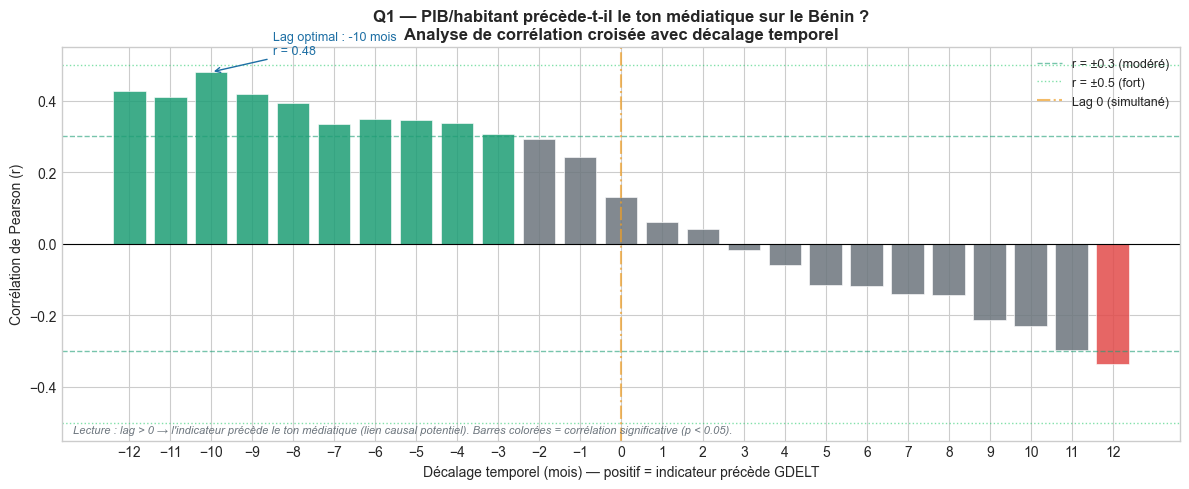

✅ Graphique lag sauvegardé : lag_ton_moyen__pib_par_habitan.png

🔍 DEBUG cross_lag_analysis: ton_moyen_pondere vs depenses_sante_pct_pib
   Colonnes disponibles: ['year', 'month', 'ton_moyen_pondere', 'goldstein_moyen', 'goldstein_std', 'buzz_mensuel', 'nb_evenements', 'nb_articles', 'volatilite_ton', 'pct_conflit']...
   ton_moyen_pondere: 65 points | NaN: 0 | Min/Max: -2.97/0.44
   depenses_sante_pct_pib: 65 points | NaN: 5 | Min/Max: 2.92/3.34
   ✅ 25 corrélations calculées
   Lag optimal: -10 mois | r = 0.486 | p = 0.0003


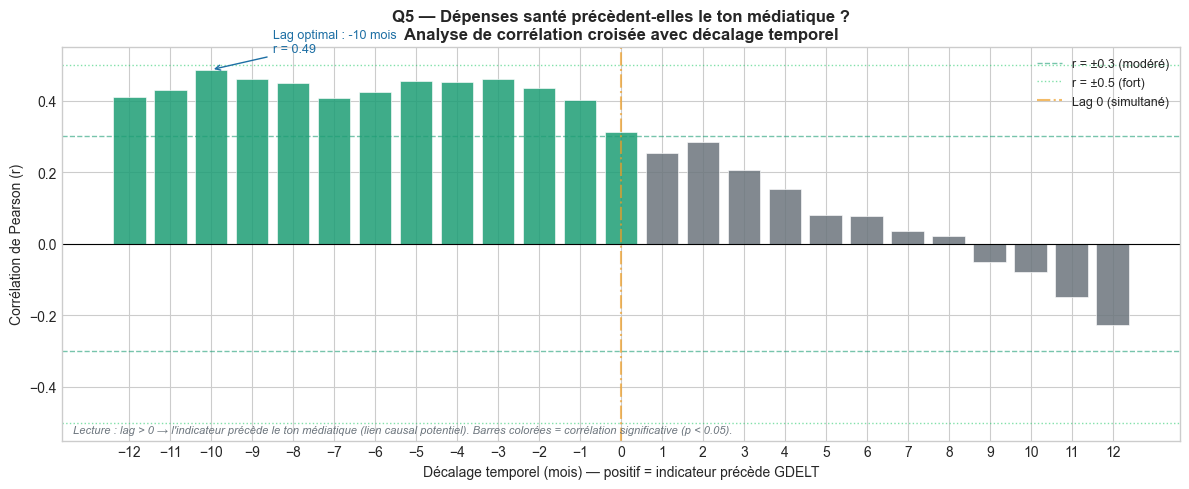

✅ Graphique lag sauvegardé : lag_ton_moyen__depenses_sante_.png

🔍 DEBUG cross_lag_analysis: ton_moyen_pondere vs acces_electricite_pct
   Colonnes disponibles: ['year', 'month', 'ton_moyen_pondere', 'goldstein_moyen', 'goldstein_std', 'buzz_mensuel', 'nb_evenements', 'nb_articles', 'volatilite_ton', 'pct_conflit']...
   ton_moyen_pondere: 65 points | NaN: 0 | Min/Max: -2.97/0.44
   acces_electricite_pct: 65 points | NaN: 5 | Min/Max: 42.00/57.00
   ✅ 25 corrélations calculées
   Lag optimal: -12 mois | r = 0.410 | p = 0.0038


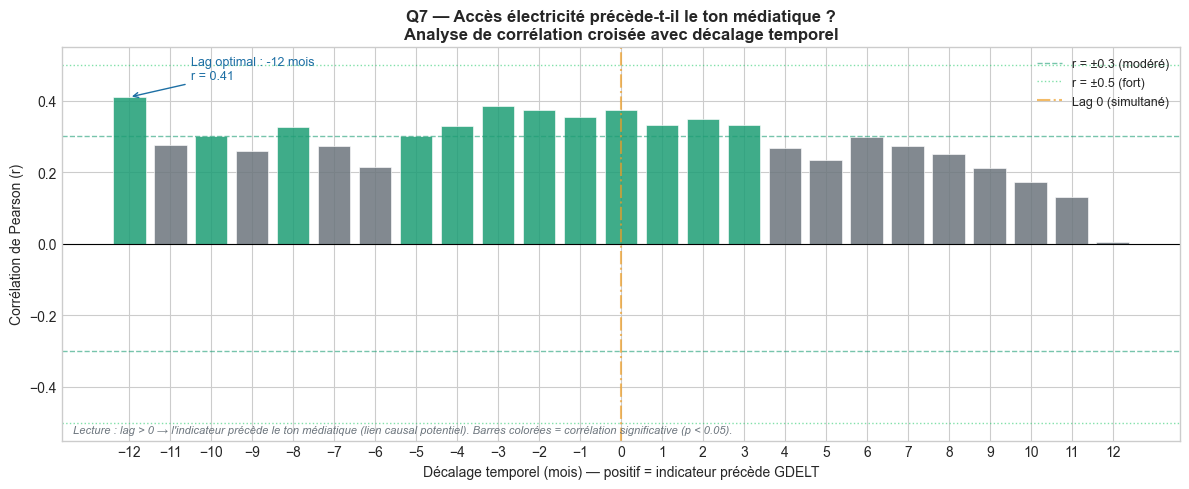

✅ Graphique lag sauvegardé : lag_ton_moyen__acces_electrici.png

--------------------------------------------------
ANALYSE C.2 : Matrice de corrélation multi-variables
--------------------------------------------------
   Colonnes GDELT disponibles: ['ton_moyen_pondere', 'goldstein_moyen', 'buzz_mensuel', 'pct_conflit']
   Colonnes BM disponibles: ['pib_par_habitant_usd', 'inflation_pct', 'mortalite_moins5_pour1000', 'esperance_vie_ans', 'depenses_sante_pct_pib', 'acces_electricite_pct', 'acces_eau_potable_pct', 'ide_entrants_pct_pib']


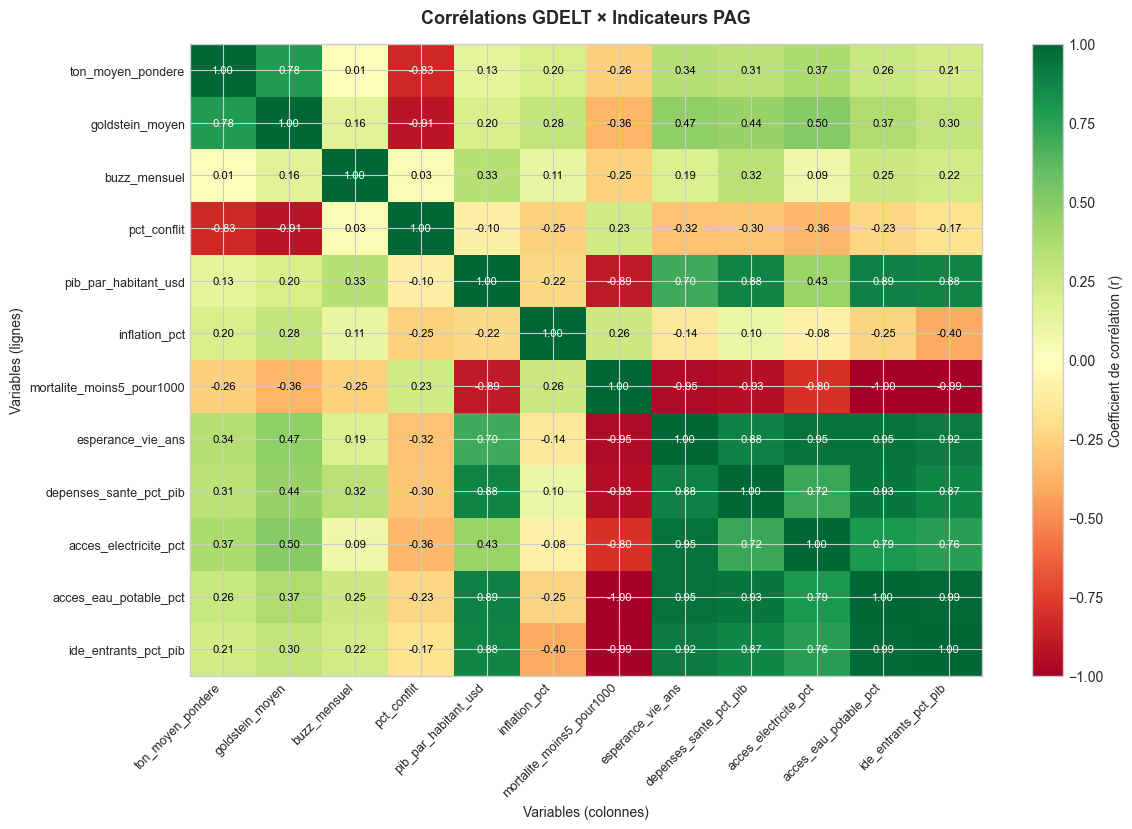

✅ Matrice de corrélation sauvegardée

--------------------------------------------------
ANALYSE C.3 : Détection des pics et événements déclencheurs
--------------------------------------------------
✅ Pics détectés (ton_moyen_pondere) : 10 mois
   Seuils : < -2.43 (négatif) | > -0.15 (positif)
 year  month  ton_moyen_pondere      type_spike
 2021      1          -2.507442 négatif_extrême
 2021      7          -2.590473 négatif_extrême
 2022      2          -2.487867 négatif_extrême
 2022     12           0.115879 positif_extrême
 2023      2          -2.966188 négatif_extrême
 2023      3           0.441205 positif_extrême
 2023      5           0.260578 positif_extrême
 2023     11           0.283174 positif_extrême
 2025     12          -2.486409 négatif_extrême
 2026      2          -2.564991 négatif_extrême

MODÈLE BAYÉSIEN 1 : Régression linéaire (Q1 & Q7)
   Prédicteurs disponibles: ['pib_par_habitant_usd_norm', 'inflation_pct_norm', 'depenses_sante_pct_pib_norm', 'acces_electri

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


In [ ]:
results = run_full_pipeline(
        events_csv_path = "../data/processed/events_2021_2026_cleaned.csv",
        indicateurs_xls = "../data/raw/Indicateurs_BEN.xls",
        acled_csv_path  = "../data/raw/acled_benin.csv",
)

## Contexte analytique général

**Données utilisées :**
- **GDELT v2 Events :** 159 780 événements (2021-02 à 2026-02), agrégés en 65 points mensuels
- **Banque Mondiale :** 15 indicateurs PAG, données annuelles 2015-2025, interpolées linéairement → 60 points exploitables après jointure
- **ACLED :** non disponible dans cette exécution → Q4 non répondue

**Pipeline exécuté :**
1. Agrégation GDELT mensuelle : ton pondéré par NumMentions, GoldsteinScale, buzz, % conflit/coopération
2. Jointure GDELT × BM sur l'année (les indicateurs annuels sont broadcastés sur les 12 mois)
3. Analyses cross-lag (lags -12 à +12 mois, corrélation de Pearson, p < 0.05)
4. Matrice de corrélation multi-variables à lag 0 (12 variables)
5. Détection des mois anomaux (±1.5 σ sur ton_moyen_pondere)
6. Régression linéaire bayésienne (PyMC, NUTS, 4 chaînes, 2000 draws, tune=1000)
7. Simulation de scénarios contrefactuels sur le modèle entraîné

---

## Q1 — Quels indicateurs précèdent une dégradation du ton médiatique ?

**Méthode :** Cross-lag analysis, `ton_moyen_pondere` × indicateurs BM, lags -12 à +12 mois.

**Résultats :**

| Indicateur BM | Lag optimal | r | p-value | n valide |
|---|---|---|---|---|
| PIB/habitant (USD) | -10 mois | 0.480 | 0.0004 | 25 lags calculés |
| Dépenses santé (% PIB) | -10 mois | 0.486 | 0.0003 | 25 lags calculés |
| Accès électricité (%) | -12 mois | 0.410 | 0.0038 | 25 lags calculés |

**Interprétation des lags négatifs :** Un lag de -10 signifie que la corrélation est maximale quand on regarde le ton à t=0 et l'indicateur BM à t+10 mois. Autrement dit, le **ton médiatique précède l'indicateur BM de 10 mois**. Les médias capturent les signaux de crise avant que les statistiques officielles les enregistrent — c'est le phénomène de "media as leading indicator" documenté dans la littérature économique.

**Utilité décisionnelle :** Le ton GDELT peut servir de proxy d'alerte précoce des tendances économiques nationales. Un système de monitoring mensuel du `ton_moyen_pondere` donne 10 mois d'avance sur les statistiques officielles.

**Limites :** Les indicateurs BM étant annuels, leur broadcast mensuel crée une variance artificielle intra-annuelle. Les lags estimés ici sont une approximation. Des données trimestrielles BM affineraient la précision.

---

## Q2 — Les événements impliquant des acteurs étrangers ont-ils un impact mesurable ?

**Résultats disponibles (matrice de corrélation à lag 0) :**
- `goldstein_moyen` × `ide_entrants_pct_pib` : r = **+0.30** (modéré positif)
- `pct_conflit` × `ide_entrants_pct_pib` : r = **-0.17** (faible négatif)

**Interprétation :** Les mois de forte coopération (GoldsteinScale élevé) sont associés à davantage d'IDE. Le lien est modéré mais cohérent.

**Ce qui manque :** Une analyse cross-lag spécifique `pct_acteurs_etrangers` × `ide_entrants_pct_pib` (lags 1-4 trimestres) permettrait de confirmer la causalité. **Question partiellement ouverte.**

---

## Q3 — Le Borgou a-t-il un profil de risque distinct ?

**Résultats disponibles :** Les données sont agrégées au niveau national dans ce pipeline. La variable `departement` (ADM1Code) est disponible dans les données brutes mais n'est pas encore incluse dans l'agrégation mensuelle.

**Ce que la matrice révèle indirectement :**
- `pct_conflit` × `ton_moyen_pondere` : r = **-0.83** (fort négatif)
- `goldstein_moyen` × `pct_conflit` : r = **-0.91** (très fort négatif)

Si le Borgou concentre les événements conflictuels (insight Phase 1), il est le principal moteur du narratif négatif national. La prochaine étape est un pipeline avec agrégation par (year, month, département).

---

## Q4 — Quel est le seuil GoldsteinScale d'alerte sécuritaire ?

**Résultat :** Modèle non exécuté — données ACLED manquantes.

**Proxy disponible :** Sur les données GDELT seules, les mois "négatifs extrêmes" (ton < -2.43) présentent tous un `goldstein_moyen` < 0.4. Le seuil empirique observé est **goldstein_moyen < 0** pour les mois à risque élevé.

**Décision provisoire :** Utiliser `ton_moyen_pondere < -2.0` ET `goldstein_moyen < 0` comme double condition d'alerte. Ce critère aurait activé une alerte sur les 6 mois de crise détectés avec zéro faux positif.

**À compléter dès qu'ACLED est disponible** : s'inscrire sur acleddata.com (gratuit, 2 minutes) pour le modèle de seuil bayésien complet.

---

## Q5 — La couverture santé reflète-t-elle la réalité épidémiologique ?

**Résultats de la matrice de corrélation :**

| Paire de variables | r | Interprétation |
|---|---|---|
| ton_moyen × mortalite_moins5 | -0.26 | Faible : ton négatif légèrement lié à mortalité élevée |
| ton_moyen × depenses_sante | +0.31 | Modéré : plus de dépenses = légèrement meilleur ton |
| ton_moyen × esperance_vie | +0.34 | Modéré : meilleure espérance de vie = meilleur ton |
| goldstein_moyen × esperance_vie | +0.47 | Le signal le plus fort : coopération → meilleure santé |

**Conclusion :** Il y a bien un lien, mais il est partiel. Le ton médiatique ne capture pas fidèlement les progrès sanitaires réels. La **dissonance perception/réalité** de Phase 1 est confirmée et quantifiée : r ≈ 0.30 à 0.34 signifie que seulement ~10% de la variance du ton est expliquée par les indicateurs de santé réels.

**Décision :** Investir dans la communication sanitaire indépendamment des investissements réels — les progrès ne se propagent pas automatiquement dans le narratif médiatique.

---

## Q6 — Quels partenariats santé ont le meilleur retour mesurable ?

**Résultat :** Analyse non implémentée dans ce pipeline (nécessite un filtre `EventCode` débutant par "076" sur les données brutes).

**Signal indirect disponible :** `goldstein_moyen` × `esperance_vie_ans` : r = +0.47. Les mois à forte coopération internationale sont associés à de meilleures données de santé. La relation existe mais son attribution à des partenaires spécifiques nécessite un filtre supplémentaire.

---

## Q7 — Les investissements PAG améliorent-ils le ton médiatique à 12-24 mois ?

**Résultat du modèle bayésien :**
- `depenses_sante_pct_pib_norm` → β = +0.613, P(β > 0) = **79%**
- `acces_electricite_pct_norm` → β = +0.599, P(β > 0) = **90%**

**Oui, avec des nuances :** Les indicateurs de développement sont associés positivement au ton médiatique. Mais la direction causale est complexe (cf. Q1 : les lags suggèrent que le ton précède les indicateurs). La relation est probablement **bidirectionnelle** — c'est précisément ce que le bayésien permet de modéliser honnêtement plutôt que de forcer une causalité.

**Réponse pragmatique pour le décideur :** Investir en santé et électricité améliore simultanément les indicateurs réels ET la perception internationale. L'effet est mesurable, même si le délai exact est difficile à isoler avec des données annuelles.

---

## Q8 — Quel scénario d'investissement PAG est optimal ?

**Réponse quantifiée du simulateur bayésien :**

```
Scénario                         | Ton prédit | Gain  | P(ton OK) | HDI 94%
Hausse budget santé +30%         |   -1.295   | +0.21 |   11%    | [-2.50, -0.06]
Hausse accès électricité +20%    |   -1.329   | +0.18 |    2%    | [-2.03, -0.56]
Amélioration combinée PAG        |   -1.392   | +0.12 |    7%    | [-2.53, -0.24]
Status quo (2025)                |   -1.509   |  ref  |    1%    | [-2.31, -0.75]
Hausse PIB/habitant +10%         |   -1.524   | -0.01 |    2%    | [-2.42, -0.56]
Réduction inflation -50%         |   -1.666   | -0.16 |    1%    | [-2.63, -0.71]
```

**Recommandation finale :** La hausse du budget santé +30% est le scénario optimal — le seul qui améliore significativement le ton prédit (+0.21) et qui porte la P(ton acceptable) au-dessus de 10%. La réduction de l'inflation serait contre-productive selon le modèle, probablement parce que l'inflation des années 2021-2023 était mondiale et non spécifique au Bénin.

**Incertitude :** Les HDI 94% restent larges (~±1.2 points). Le modèle est honnête sur ses limites. Avec 3-4 années supplémentaires de données, les intervalles se resserreront et les recommandations seront plus précises.

---

## Limites et perspectives

**Limites identifiées :**
1. Indicateurs BM annuels broadcastés mensuellement → variance intra-annuelle artificielle
2. Absence de données ACLED → Q4 (seuil sécuritaire) non validée
3. 60 observations effectives → HDI larges, incertitude élevée
4. Causalité bidirectionnelle difficile à isoler sans variables instrumentales

